In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss

In [7]:
file_path = "india_monthly_exports_with_indicators (1).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Monthly Totals"
)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (96, 5)
Columns:
['Date', 'Export_Value', 'gdp_growth', 'Inflation_rate', 'REER']


Convert Date to datetime

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Set Date as index
df = df.set_index("Date")


In [4]:
var_df = df[
    [
        "Export_Value",
        "gdp_growth",
        "Inflation_rate",
        "REER"
    ]
].copy()

In [12]:
print("\nDescriptive Statistics:")
display(var_df.describe().round(3))


Descriptive Statistics:


,Export_Value,gdp_growth,Inflation_rate,REER
count,96.000,96.000,96.000,96.000
mean,32150.601,5.752,4.853,99.513
std,6228.883,5.565,1.704,2.431
min,10173.280,-23.900,0.250,92.890
25%,26818.115,5.183,3.680,97.818
50%,33589.715,7.000,4.970,99.815
75%,37017.588,7.675,6.105,101.292
max,44573.670,20.100,7.790,104.720


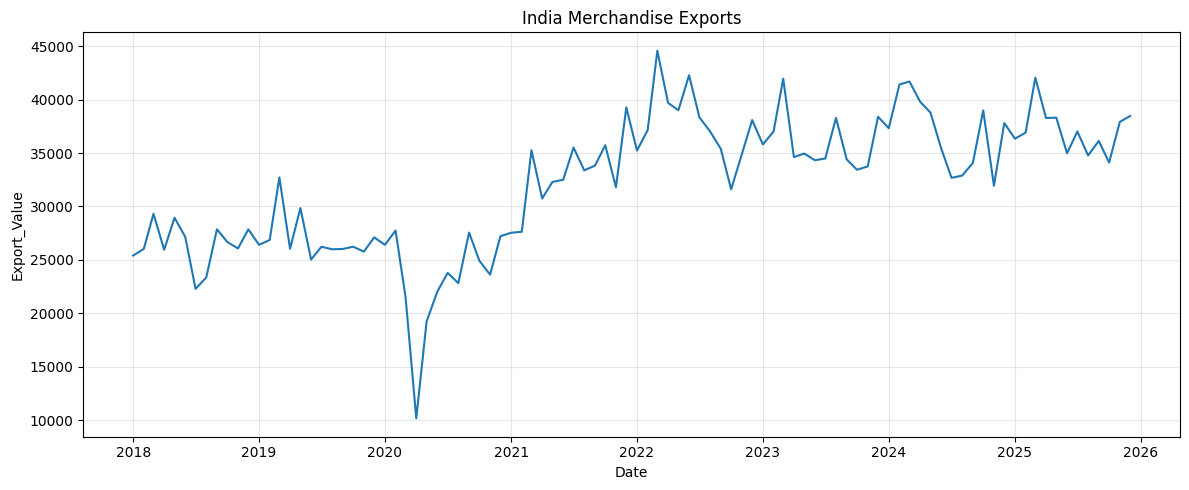

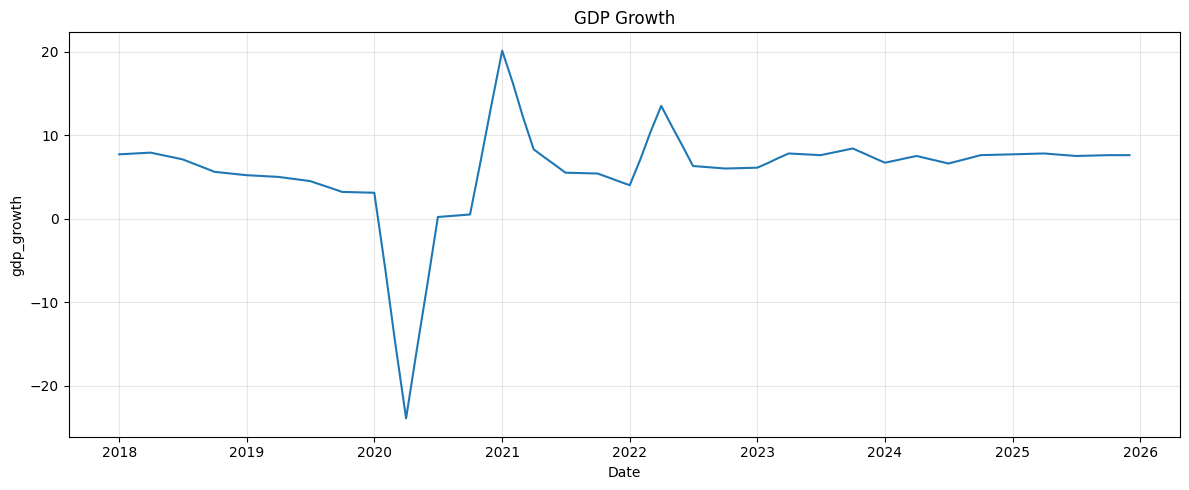

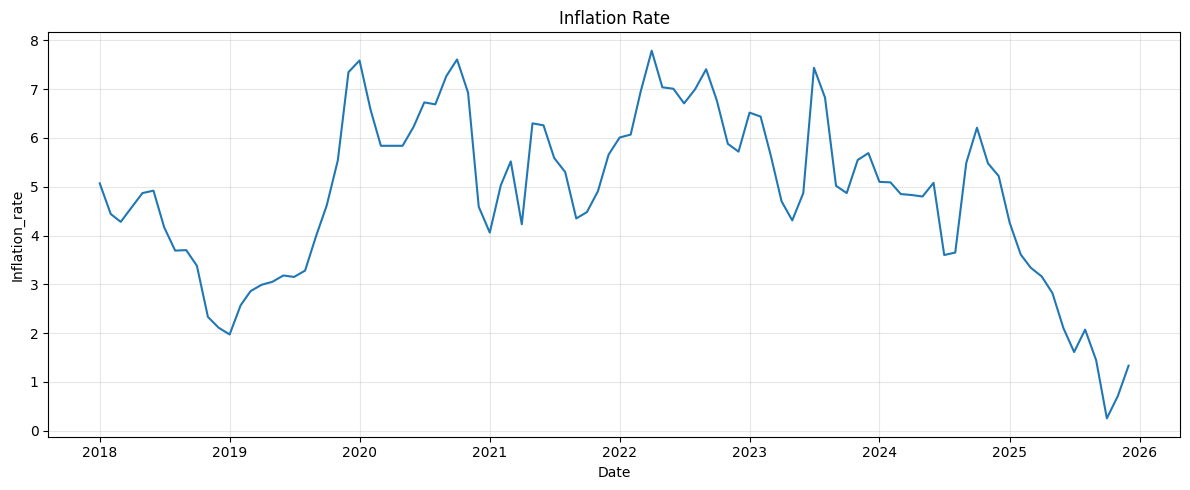

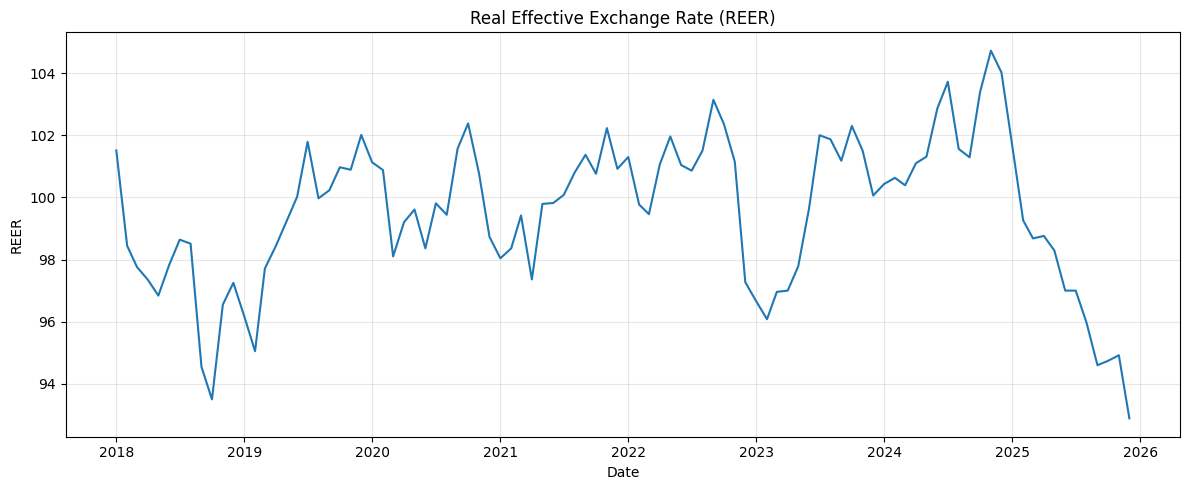

In [13]:

# TIME-SERIES PLOTS
variables = {
    "Export_Value": "India Merchandise Exports",
    "gdp_growth": "GDP Growth",
    "Inflation_rate": "Inflation Rate",
    "REER": "Real Effective Exchange Rate (REER)"
}

for column, title in variables.items():

    plt.figure(figsize=(12, 5))

    plt.plot(var_df.index, var_df[column])

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(column)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

AUGMENTED DICKEY-FULLER (ADF) TEST

In [19]:
def adf_test(series, name):

    result = adfuller(
        series.dropna(),
        autolag="AIC"
    )

    return {
        "Variable": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Critical Value (1%)": result[4]["1%"],
        "Critical Value (5%)": result[4]["5%"],
        "Critical Value (10%)": result[4]["10%"],
        "Conclusion": (
            "Stationary"
            if result[1] < 0.05
            else "Non-Stationary"
        )
    }


adf_results = []

for column in var_df.columns:

    adf_results.append(
        adf_test(
            var_df[column],
            column
        )
    )

adf_table = pd.DataFrame(adf_results)

print("ADF TEST RESULTS")
display(adf_table.round(4))

ADF TEST RESULTS


,Variable,ADF Statistic,p-value,Lags Used,Observations,Critical Value (1%),Critical Value (5%),Critical Value (10%),Conclusion
0,Export_Value,-2.0152,0.2800,1,94,-3.5019,-2.8928,-2.5835,Non-Stationary
1,gdp_growth,-3.9020,0.0020,4,91,-3.5043,-2.8939,-2.5840,Stationary
2,Inflation_rate,-1.5773,0.4950,12,83,-3.5117,-2.8970,-2.5857,Non-Stationary
3,REER,-2.5915,0.0948,1,94,-3.5019,-2.8928,-2.5835,Non-Stationary


In [20]:

# KPSS TEST
def kpss_test(series, name):

    try:

        statistic, p_value, lags, critical_values = kpss(
            series.dropna(),
            regression="c",
            nlags="auto"
        )

        return {
            "Variable": name,
            "KPSS Statistic": statistic,
            "p-value": p_value,
            "Lags Used": lags,
            "Critical Value (5%)": critical_values["5%"],
            "Conclusion": (
                "Stationary"
                if p_value >= 0.05
                else "Non-Stationary"
            )
        }

    except Exception as e:

        return {
            "Variable": name,
            "KPSS Statistic": np.nan,
            "p-value": np.nan,
            "Lags Used": np.nan,
            "Critical Value (5%)": np.nan,
            "Conclusion": f"Error: {e}"
        }


kpss_results = []

for column in var_df.columns:

    kpss_results.append(
        kpss_test(
            var_df[column],
            column
        )
    )

kpss_table = pd.DataFrame(kpss_results)

print("KPSS TEST RESULTS")
display(kpss_table.round(4))

KPSS TEST RESULTS


/tmp/ipykernel_677/1798187348.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_677/1798187348.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_677/1798187348.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/tmp/ipykernel_677/1798187348.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, crit

,Variable,KPSS Statistic,p-value,Lags Used,Critical Value (5%),Conclusion
0,Export_Value,1.2094,0.01,5,0.463,Non-Stationary
1,gdp_growth,0.2648,0.10,5,0.463,Stationary
2,Inflation_rate,0.3018,0.10,5,0.463,Stationary
3,REER,0.1935,0.10,5,0.463,Stationary


In [21]:
# ============================================================
# COMBINED STATIONARITY TABLE
# ============================================================

stationarity_table = adf_table[
    [
        "Variable",
        "ADF Statistic",
        "p-value",
        "Conclusion"
    ]
].copy()

stationarity_table = stationarity_table.rename(
    columns={
        "ADF Statistic": "ADF Statistic",
        "p-value": "ADF p-value",
        "Conclusion": "ADF Conclusion"
    }
)

stationarity_table["KPSS Statistic"] = kpss_table[
    "KPSS Statistic"
].values

stationarity_table["KPSS p-value"] = kpss_table[
    "p-value"
].values

stationarity_table["KPSS Conclusion"] = kpss_table[
    "Conclusion"
].values

display(
    stationarity_table.round(4)
)

,Variable,ADF Statistic,ADF p-value,ADF Conclusion,KPSS Statistic,KPSS p-value,KPSS Conclusion
0,Export_Value,-2.0152,0.2800,Non-Stationary,1.2094,0.01,Non-Stationary
1,gdp_growth,-3.9020,0.0020,Stationary,0.2648,0.10,Stationary
2,Inflation_rate,-1.5773,0.4950,Non-Stationary,0.3018,0.10,Stationary
3,REER,-2.5915,0.0948,Non-Stationary,0.1935,0.10,Stationary


FIRST DIFFERENCE STATIONARITY TEST

In [25]:

# Variables identified as non-stationary / requiring further
# investigation based on the level stationarity results

diff_variables = [
    "Export_Value",
    "Inflation_rate",
    "REER"
]

first_diff_results = []

for column in diff_variables:

    # First difference
    series_diff = var_df[column].diff().dropna()

    # -------------------------
    # ADF test
    # -------------------------
    adf_result = adfuller(
        series_diff,
        autolag="AIC"
    )

    adf_stat = adf_result[0]
    adf_p = adf_result[1]

    adf_conclusion = (
        "Stationary"
        if adf_p < 0.05
        else "Non-Stationary"
    )

    # -------------------------
    # KPSS test
    # -------------------------
    try:

        kpss_stat, kpss_p, kpss_lags, kpss_critical = kpss(
            series_diff,
            regression="c",
            nlags="auto"
        )

        kpss_conclusion = (
            "Stationary"
            if kpss_p >= 0.05
            else "Non-Stationary"
        )

    except Exception:

        kpss_stat = np.nan
        kpss_p = np.nan
        kpss_lags = np.nan
        kpss_conclusion = "Test Error"

    # -------------------------
    # Store results
    # -------------------------

    first_diff_results.append({
        "Variable": column,
        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Conclusion": adf_conclusion,
        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Conclusion": kpss_conclusion
    })


first_diff_table = pd.DataFrame(first_diff_results)

print("FIRST-DIFFERENCE STATIONARITY RESULTS")

display(
    first_diff_table.round(4)
)

FIRST-DIFFERENCE STATIONARITY RESULTS


/tmp/ipykernel_677/1677798035.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_critical = kpss(
/tmp/ipykernel_677/1677798035.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_critical = kpss(
/tmp/ipykernel_677/1677798035.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_critical = kpss(


,Variable,ADF Statistic,ADF p-value,ADF Conclusion,KPSS Statistic,KPSS p-value,KPSS Conclusion
0,Export_Value,-9.6290,0.000,Stationary,0.0742,0.1,Stationary
1,Inflation_rate,-3.2979,0.015,Stationary,0.1583,0.1,Stationary
2,REER,-8.8225,0.000,Stationary,0.1165,0.1,Stationary


FINAL STATIONARY VARIABLES FOR VAR

In [26]:


var_stationary = pd.DataFrame(index=var_df.index)

# ------------------------------------------------------------
# 1. Export growth
# ------------------------------------------------------------
# Log difference of exports
var_stationary["Export_Growth"] = (
    np.log(var_df["Export_Value"]).diff() * 100
)

# ------------------------------------------------------------
# 2. GDP Growth
# ------------------------------------------------------------
# Already stationary at level
var_stationary["GDP_Growth"] = var_df["gdp_growth"]

# ------------------------------------------------------------
# 3. Inflation
# ------------------------------------------------------------
# First difference
var_stationary["Inflation_Change"] = (
    var_df["Inflation_rate"].diff()
)

# ------------------------------------------------------------
# 4. REER
# ------------------------------------------------------------
# First difference
var_stationary["REER_Change"] = (
    var_df["REER"].diff()
)

# ------------------------------------------------------------
# Remove missing observations
# ------------------------------------------------------------

var_stationary = var_stationary.dropna()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Final stationary VAR dataset:")
display(var_stationary.head())

print("\nShape:")
print(var_stationary.shape)

print("\nMissing values:")
print(var_stationary.isnull().sum())

print("\nDescriptive statistics:")
display(var_stationary.describe().round(3))

Final stationary VAR dataset:


,Export_Growth,GDP_Growth,Inflation_Change,REER_Change
Date,,,,
2018-02-01,2.424238,7.766667,-0.63,-3.07
2018-03-01,11.878720,7.833333,-0.16,-0.68
2018-04-01,-12.199445,7.900000,0.30,-0.41
2018-05-01,10.924207,7.633333,0.29,-0.51
2018-06-01,-6.372015,7.366667,0.05,0.99



Shape:
(95, 4)

Missing values:
Export_Growth       0
GDP_Growth          0
Inflation_Change    0
REER_Change         0
dtype: int64

Descriptive statistics:


,Export_Growth,GDP_Growth,Inflation_Change,REER_Change
count,95.000,95.000,95.000,95.000
mean,0.437,5.732,-0.039,-0.091
std,14.362,5.591,0.767,1.379
min,-74.786,-23.900,-2.340,-3.960
25%,-5.981,5.167,-0.600,-0.900
50%,0.642,6.967,-0.030,0.000
75%,7.852,7.667,0.400,0.810
max,63.757,20.100,2.570,3.050


In [28]:
# ============================================================
# STEP 9 — VAR LAG ORDER SELECTION
# ============================================================

from statsmodels.tsa.api import VAR

# ------------------------------------------------------------
# 1. Create VAR model object
# ------------------------------------------------------------

var_model = VAR(var_stationary)

# ------------------------------------------------------------
# 2. Test different lag lengths
# ------------------------------------------------------------

lag_selection = var_model.select_order(maxlags=12)

print("VAR LAG ORDER SELECTION")
print(lag_selection.summary())

VAR LAG ORDER SELECTION
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        8.891       9.007       7263.       8.937
1        7.146       7.728       1269.       7.380
2        6.602      7.651*       739.2      7.024*
3        6.704       8.219       824.0       7.313
4        6.456       8.437       651.4       7.252
5        6.300       8.748       569.4       7.283
6        6.216       9.130      540.6*       7.386
7        6.227       9.607       572.2       7.585
8        6.155       10.00       567.3       7.701
9        6.098       10.41       582.3       7.831
10       6.089       10.87       643.9       8.009
11       6.189       11.43       820.2       8.297
12      5.680*       11.39       591.7       7.975
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [30]:
# ============================================================
# STEP 10 — ESTIMATE VAR(2)
# ============================================================

from statsmodels.tsa.api import VAR

# Create VAR model
var_model = VAR(var_stationary)

# Estimate VAR with 2 lags
var_result = var_model.fit(2)

# Display model summary
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 10, Aug, 2026
Time:                     11:23:58
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    7.38024
Nobs:                     93.0000    HQIC:                   6.79572
Log likelihood:          -789.439    FPE:                    603.236
AIC:                      6.39988    Det(Omega_mle):         416.887
--------------------------------------------------------------------
Results for equation Export_Growth
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                      -0.062941         1.880783           -0.033           0.973
L1.Export_Growth           -0.695308         0.114656           -6.064           0.000
L1.GDP_Growth               

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
# ============================================================
# STEP 11A — VAR STABILITY CHECK
# ============================================================

roots = var_result.roots

print("VAR roots:")
print(roots)

print("\nAbsolute values of roots:")
print(np.abs(roots))

if np.all(np.abs(roots) > 1):
    print("\nRESULT: VAR(2) is STABLE.")
else:
    print("\nRESULT: VAR(2) is NOT STABLE.")

  # ============================================================
# STEP 11B — RESIDUAL SERIAL CORRELATION
# ============================================================

serial_test = var_result.test_whiteness(
    nlags=12,
    adjusted=True
)

print(serial_test.summary())
# ============================================================
# STEP 11C — RESIDUAL NORMALITY TEST
# ============================================================

normality_test = var_result.test_normality()

print(normality_test.summary())

# ============================================================
# STEP 11D — RESIDUAL HETEROSKEDASTICITY
# ============================================================

from statsmodels.stats.diagnostic import het_arch

residuals = var_result.resid

for column in residuals.columns:

    test_stat, p_value, _, _ = het_arch(
        residuals[column],
        nlags=12
    )

    print(f"\n{column}")
    print(f"ARCH test statistic: {test_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Result: Evidence of ARCH effects / heteroskedasticity")
    else:
        print("Result: No significant ARCH effects detected")

VAR roots:
[ 0.37913756-2.82969151j  0.37913756+2.82969151j -0.78206231-1.5558474j
 -0.78206231+1.5558474j   0.24721685+1.50912699j  0.24721685-1.50912699j
  1.18455428+0.51952796j  1.18455428-0.51952796j]

Absolute values of roots:
[2.85497799 2.85497799 1.74134505 1.74134505 1.52924179 1.52924179
 1.29347522 1.29347522]

RESULT: VAR(2) is STABLE.
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         254.5          190.5   0.000 160
-----------------------------------------
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         686.2          15.51   0.000  8
----------------------------------------

Export_Growth
ARCH te

In [37]:
# ============================================================
# STEP 11E — MODEL DIAGNOSTIC SUMMARY
# ============================================================

print("=" * 60)
print("VAR(2) DIAGNOSTIC SUMMARY")
print("=" * 60)

# Stability
print("\n1. Stability")
if np.all(np.abs(var_result.roots) > 1):
    print("PASS — All roots satisfy the stability condition.")
else:
    print("WARNING — Stability condition is not satisfied.")

# Serial correlation
print("\n2. Residual Serial Correlation")
print(serial_test.summary())

# Normality
print("\n3. Residual Normality")
print(normality_test.summary())

# Heteroskedasticity
print("\n4. Residual Heteroskedasticity")
for column in residuals.columns:

    test_stat, p_value, _, _ = het_arch(
        residuals[column],
        nlags=12
    )

    print(
        f"{column}: p-value = {p_value:.4f}"
    )

VAR(2) DIAGNOSTIC SUMMARY

1. Stability
PASS — All roots satisfy the stability condition.

2. Residual Serial Correlation
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         254.5          190.5   0.000 160
-----------------------------------------

3. Residual Normality
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         686.2          15.51   0.000  8
----------------------------------------

4. Residual Heteroskedasticity
Export_Growth: p-value = 0.9635
GDP_Growth: p-value = 0.0073
Inflation_Change: p-value = 0.7410
REER_Change: p-value = 0.6520


In [39]:
# ============================================================
# STEP 11 — CHECK ALTERNATIVE VAR LAGS
# ============================================================

from statsmodels.tsa.api import VAR

candidate_results = []

for lag in range(2, 13):

    model = VAR(var_stationary)
    result = model.fit(lag)

    # --------------------------------------------------------
    # Stability
    # --------------------------------------------------------

    stable = np.all(np.abs(result.roots) > 1)

    # --------------------------------------------------------
    # Residual autocorrelation
    # nlags must be greater than model lag
    # --------------------------------------------------------

    test_lag = max(13, lag + 1)

    whiteness = result.test_whiteness(
        nlags=test_lag,
        adjusted=True
    )

    whiteness_p = whiteness.pvalue

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    candidate_results.append({
        "Lag": lag,
        "AIC": result.aic,
        "BIC": result.bic,
        "HQIC": result.hqic,
        "FPE": result.fpe,
        "Stable": stable,
        "Whiteness p-value": whiteness_p
    })


candidate_table = pd.DataFrame(candidate_results)

display(
    candidate_table.round(4)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,Lag,AIC,BIC,HQIC,FPE,Stable,Whiteness p-value
0,2,6.3999,7.3802,6.7957,603.2363,True,0.0000
1,3,6.5072,7.9326,7.0825,675.1021,True,0.0000
2,4,6.2845,8.1607,7.0414,545.7920,True,0.0000
3,5,6.1559,8.4890,7.0967,488.2813,True,0.0001
4,6,6.1179,8.9141,7.2450,482.9867,True,0.0003
5,7,6.2637,9.5292,7.5793,581.6332,True,0.0001
6,8,6.1861,9.9275,7.6926,570.0117,True,0.0000
7,9,6.0698,10.2936,7.7697,549.7247,True,0.0000
8,10,5.9773,10.6902,7.8729,559.3727,True,0.0000
9,11,6.1566,11.3655,8.2505,777.3192,True,0.0000


this will show us where the remaining autocorrelation is occurring.


Residual diagnostics: Export_Growth


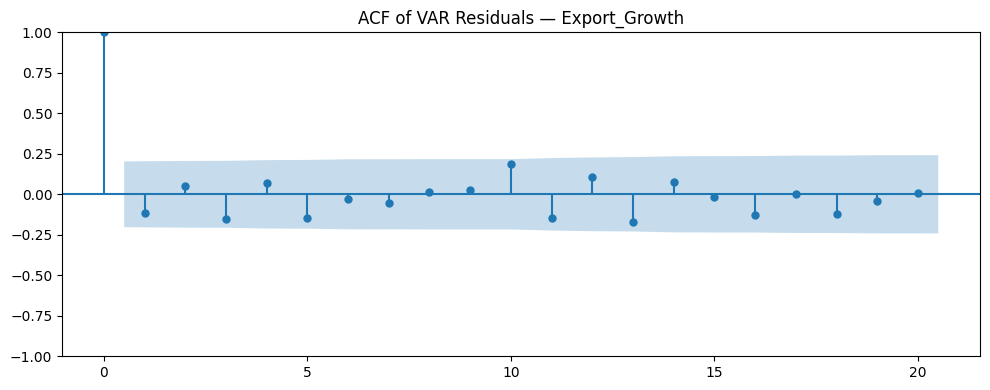


Residual diagnostics: GDP_Growth


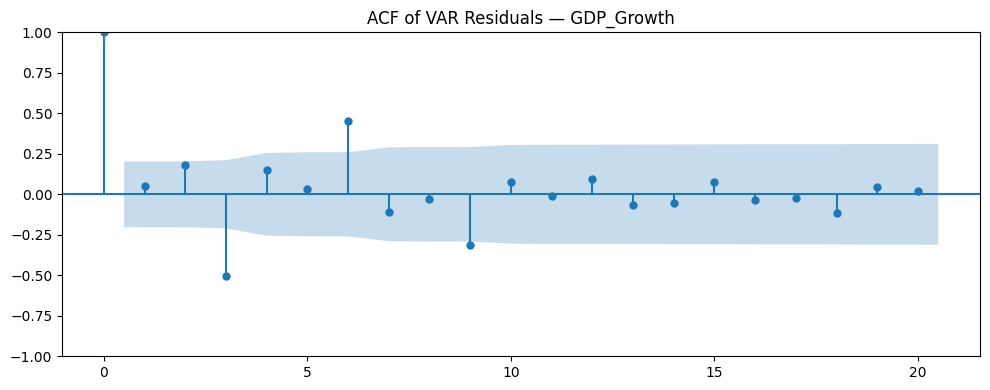


Residual diagnostics: Inflation_Change


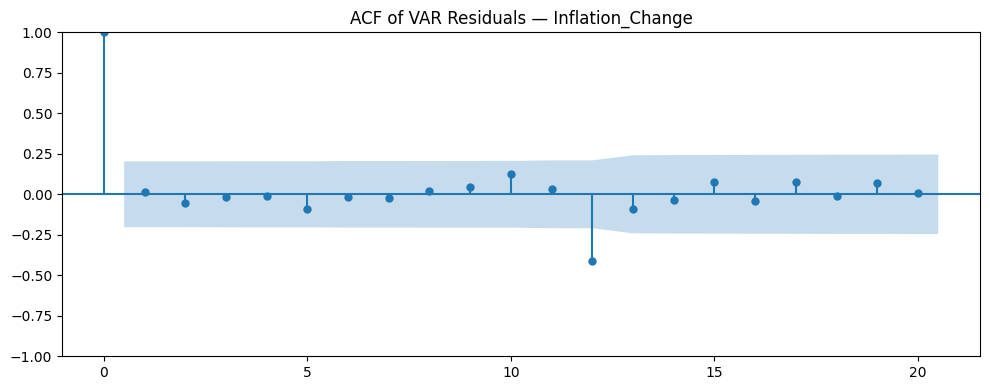


Residual diagnostics: REER_Change


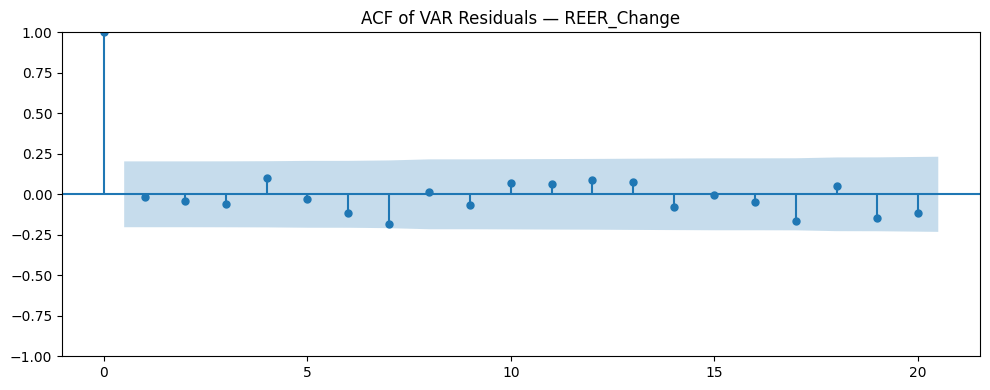

In [40]:
# ============================================================
# RESIDUAL ACF/PACF CHECK
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

residuals = var_result.resid

for column in residuals.columns:

    print(f"\nResidual diagnostics: {column}")

    fig, ax = plt.subplots(figsize=(10, 4))

    plot_acf(
        residuals[column],
        lags=20,
        ax=ax
    )

    ax.set_title(
        f"ACF of VAR Residuals — {column}"
    )

    plt.tight_layout()
    plt.show()

<Figure size 1000x400 with 0 Axes>

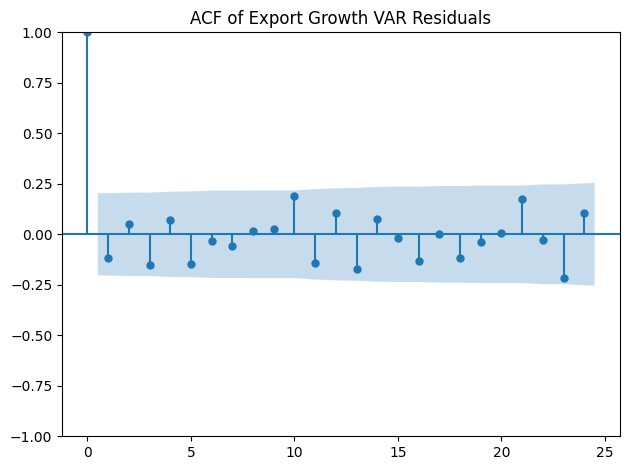

In [41]:
# Export residual autocorrelation

export_resid = var_result.resid["Export_Growth"]

plt.figure(figsize=(10, 4))

plot_acf(
    export_resid,
    lags=24
)

plt.title("ACF of Export Growth VAR Residuals")
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# STEP 12A — JOINT GRANGER CAUSALITY FOR EXPORT GROWTH
# ============================================================

test_export = var_result.test_causality(
    caused="Export_Growth",
    causing=[
        "GDP_Growth",
        "Inflation_Change",
        "REER_Change"
    ],
    kind="f"
)

print(test_export.summary())

Granger causality F-test. H_0: ['GDP_Growth', 'Inflation_Change', 'REER_Change'] do not Granger-cause Export_Growth. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         3.860          2.126   0.001 (6, 336)
----------------------------------------------


In [43]:
# ============================================================
# STEP 12B — INDIVIDUAL GRANGER CAUSALITY TESTS
# ============================================================

causes = [
    "GDP_Growth",
    "Inflation_Change",
    "REER_Change"
]

for cause in causes:

    test = var_result.test_causality(
        caused="Export_Growth",
        causing=[cause],
        kind="f"
    )

    print("\n" + "="*60)
    print(f"{cause} → Export_Growth")
    print("="*60)
    print(test.summary())


GDP_Growth → Export_Growth
Granger causality F-test. H_0: GDP_Growth does not Granger-cause Export_Growth. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         10.25          3.023   0.000 (2, 336)
----------------------------------------------

Inflation_Change → Export_Growth
Granger causality F-test. H_0: Inflation_Change does not Granger-cause Export_Growth. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         2.409          3.023   0.091 (2, 336)
----------------------------------------------

REER_Change → Export_Growth
Granger causality F-test. H_0: REER_Change does not Granger-cause Export_Growth. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.8066          3.023

In [44]:
# ============================================================
# STEP 12C — REVERSE GRANGER CAUSALITY
# ============================================================

reverse_tests = [
    ("Export_Growth", "GDP_Growth"),
    ("Export_Growth", "Inflation_Change"),
    ("Export_Growth", "REER_Change")
]

for causing, caused in reverse_tests:

    test = var_result.test_causality(
        caused=caused,
        causing=[causing],
        kind="f"
    )

    print("\n" + "="*65)
    print(f"{causing} → {caused}")
    print("="*65)
    print(test.summary())


Export_Growth → GDP_Growth
Granger causality F-test. H_0: Export_Growth does not Granger-cause GDP_Growth. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         3.266          3.023   0.039 (2, 336)
----------------------------------------------

Export_Growth → Inflation_Change
Granger causality F-test. H_0: Export_Growth does not Granger-cause Inflation_Change. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.5033          3.023   0.605 (2, 336)
----------------------------------------------

Export_Growth → REER_Change
Granger causality F-test. H_0: Export_Growth does not Granger-cause REER_Change. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         3.700          3.023   0.026